In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, HistGradientBoostingRegressor
import optuna
import joblib
import warnings
from tqdm import TqdmWarning

warnings.filterwarnings("ignore", category=TqdmWarning)

Cargamos los datos para nuestro modelo

In [10]:
df = pd.read_csv("../csv/clean_cars.csv")

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 192378 entries, 0 to 192377
Data columns (total 76 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   brand                192378 non-null  object 
 1   model                192378 non-null  object 
 2   model_year           192378 non-null  int64  
 3   milage               192378 non-null  int64  
 4   fuel_type            192378 non-null  object 
 5   transmission         192378 non-null  object 
 6   ext_col              192378 non-null  object 
 7   int_col              192378 non-null  object 
 8   accident             192378 non-null  int64  
 9   clean_title          192378 non-null  int64  
 10  price                192378 non-null  int64  
 11  brand_Alfa           192378 non-null  bool   
 12  brand_Aston          192378 non-null  bool   
 13  brand_Audi           192378 non-null  bool   
 14  brand_BMW            192378 non-null  bool   
 15  brand_Bentley    

#### Preparamos x e y

In [11]:
# Target
y = df['price']

# Features (SOLO numéricas)
x = df.drop(columns=[
    'price',
    'brand',
    'transmission',
    'int_col',
    'ext_col',
    'model',
    'fuel_type',
])

y_log = np.log1p(y)

x_train, x_test, y_train, y_test = train_test_split(
    x, y_log, test_size=0.2, random_state=42
)

y_test_real = np.expm1(y_test)


#### Métricas de evaluación

In [12]:
def evaluate_model(y_true, y_pred):
    return{
        'MAE': mean_absolute_error(y_true, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'R2': r2_score(y_true, y_pred)
    }

#### Optimización de Hiperparametros con optuna

##### Random Forest (RF)

In [13]:
def objective_rf(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 600),
        "max_depth": trial.suggest_int("max_depth", 3, 30),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 10),
        "max_features": trial.suggest_categorical("max_features", ["sqrt", "log2"]),
        "random_state": 42,
        "n_jobs": -1
    }

    model = RandomForestRegressor(**params)

    score = cross_val_score(
        model,
        x,
        y,
        cv=5,
        scoring="neg_root_mean_squared_error"
    ).mean()

    return -score

##### Gradient Boosting (GBR)

In [14]:
def objective_gb(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 500),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 10),
        "random_state": 42
    }

    model = GradientBoostingRegressor(**params)

    score = cross_val_score(
        model,
        x,
        y,
        cv=5,
        scoring="neg_root_mean_squared_error"
    ).mean()

    return -score


##### Hist Gradient Boosting Regressor (HGB)

In [15]:
def objective_hgb(trial):
    params = {
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "max_depth": trial.suggest_int("max_depth", 3, 15),
        "max_iter": trial.suggest_int("max_iter", 100, 600),
        "l2_regularization": trial.suggest_float("l2_regularization", 1e-6, 10.0, log=True),
        "max_leaf_nodes": trial.suggest_int("max_leaf_nodes", 15, 255),
        "random_state": 42
    }

    model = HistGradientBoostingRegressor(**params)

    score = cross_val_score(
        model,
        x,
        y,
        cv=5,
        scoring="neg_root_mean_squared_error"
    ).mean()

    return -score

#### Ejecutar Optuna

##### RF

In [16]:
study_rf = optuna.create_study(direction="minimize")
study_rf.optimize(objective_rf, n_trials=5)

print("Mejores hiperparámetros:")
print(study_rf.best_params)
print("Mejor RMSE:", study_rf.best_value)

[I 2026-02-02 10:25:24,798] A new study created in memory with name: no-name-c451e4bc-ac8c-4edb-9e94-f3c7ae991148
[I 2026-02-02 10:29:35,021] Trial 0 finished with value: 39998.76339409317 and parameters: {'n_estimators': 591, 'max_depth': 15, 'min_samples_split': 4, 'min_samples_leaf': 6, 'max_features': 'log2'}. Best is trial 0 with value: 39998.76339409317.
[I 2026-02-02 10:32:00,000] Trial 1 finished with value: 39563.897439692446 and parameters: {'n_estimators': 219, 'max_depth': 24, 'min_samples_split': 8, 'min_samples_leaf': 5, 'max_features': 'sqrt'}. Best is trial 1 with value: 39563.897439692446.
[I 2026-02-02 10:34:23,628] Trial 2 finished with value: 39745.69280931745 and parameters: {'n_estimators': 267, 'max_depth': 23, 'min_samples_split': 4, 'min_samples_leaf': 6, 'max_features': 'log2'}. Best is trial 1 with value: 39563.897439692446.
[I 2026-02-02 10:36:06,620] Trial 3 finished with value: 41283.22521258928 and parameters: {'n_estimators': 431, 'max_depth': 8, 'min_sa

Mejores hiperparámetros:
{'n_estimators': 219, 'max_depth': 24, 'min_samples_split': 8, 'min_samples_leaf': 5, 'max_features': 'sqrt'}
Mejor RMSE: 39563.897439692446


##### GBR

In [18]:
study_gbr = optuna.create_study(direction="minimize")
study_gbr.optimize(objective_gb, n_trials=3)

print("Mejores hiperparámetros:")
print(study_gbr.best_params)
print("Mejor RMSE:", study_gbr.best_value)

[I 2026-02-02 11:02:30,566] A new study created in memory with name: no-name-ce63b556-ca30-4f55-8eab-55c6d9e806ee
[I 2026-02-02 11:12:33,744] Trial 0 finished with value: 39718.80129472494 and parameters: {'n_estimators': 267, 'learning_rate': 0.01719711434564939, 'max_depth': 5, 'subsample': 0.8949658149999584, 'min_samples_split': 12, 'min_samples_leaf': 6}. Best is trial 0 with value: 39718.80129472494.
[I 2026-02-02 11:24:47,338] Trial 1 finished with value: 41577.550850483865 and parameters: {'n_estimators': 203, 'learning_rate': 0.15455793840272655, 'max_depth': 10, 'subsample': 0.7687189434666685, 'min_samples_split': 10, 'min_samples_leaf': 2}. Best is trial 0 with value: 39718.80129472494.
[I 2026-02-02 11:52:15,881] Trial 2 finished with value: 41914.49535970834 and parameters: {'n_estimators': 391, 'learning_rate': 0.26525217760647773, 'max_depth': 8, 'subsample': 0.9755293002635955, 'min_samples_split': 20, 'min_samples_leaf': 2}. Best is trial 0 with value: 39718.801294724

Mejores hiperparámetros:
{'n_estimators': 267, 'learning_rate': 0.01719711434564939, 'max_depth': 5, 'subsample': 0.8949658149999584, 'min_samples_split': 12, 'min_samples_leaf': 6}
Mejor RMSE: 39718.80129472494


##### HGB

In [19]:
study_hgb = optuna.create_study(direction="minimize")
study_hgb.optimize(objective_hgb, n_trials=10)

print("Mejores hiperparámetros:")
print(study_hgb.best_params)
print("Mejor RMSE:", study_hgb.best_value)

[I 2026-02-02 11:52:15,902] A new study created in memory with name: no-name-b4e08089-4691-4870-97ee-ad4f00edb99f
[I 2026-02-02 11:52:43,154] Trial 0 finished with value: 39944.868737059136 and parameters: {'learning_rate': 0.019964207173878996, 'max_depth': 3, 'max_iter': 350, 'l2_regularization': 2.966315137082154e-06, 'max_leaf_nodes': 130}. Best is trial 0 with value: 39944.868737059136.
[I 2026-02-02 11:52:50,648] Trial 1 finished with value: 39684.00451490939 and parameters: {'learning_rate': 0.24267611430735506, 'max_depth': 8, 'max_iter': 141, 'l2_regularization': 0.0006974750656681403, 'max_leaf_nodes': 25}. Best is trial 1 with value: 39684.00451490939.
[I 2026-02-02 11:53:37,568] Trial 2 finished with value: 39766.615579848105 and parameters: {'learning_rate': 0.016448629829686867, 'max_depth': 12, 'max_iter': 151, 'l2_regularization': 3.6549298498056113, 'max_leaf_nodes': 118}. Best is trial 1 with value: 39684.00451490939.
[I 2026-02-02 11:53:51,584] Trial 3 finished with 

Mejores hiperparámetros:
{'learning_rate': 0.08723137195475782, 'max_depth': 4, 'max_iter': 296, 'l2_regularization': 0.48570475130771695, 'max_leaf_nodes': 115}
Mejor RMSE: 39617.86392940301


#### Random Forest Regressor

In [21]:
# Random Forest
rf = RandomForestRegressor(
    **study_rf.best_params,
    random_state=42,
    n_jobs=1
)

rf.fit(x_train, y_train)

# Predicciones (log → real)
y_pred_rf_train = np.expm1(rf.predict(x_train))
y_pred_rf_test  = np.expm1(rf.predict(x_test))

#### Gradient Boosting

In [22]:
# Gradient Boosting
gbr = GradientBoostingRegressor(
    **study_gbr.best_params,
    random_state=42
)

gbr.fit(x_train, y_train)

# Predicciones (log → real)
y_pred_gbr_train = np.expm1(gbr.predict(x_train))
y_pred_gbr_test  = np.expm1(gbr.predict(x_test))

####  HGB

In [23]:
hgb = HistGradientBoostingRegressor(
    **study_hgb.best_params,
    random_state=42
)

hgb.fit(x_train, y_train)

# Predicciones (log → real)
y_pred_hgb_train = np.expm1(hgb.predict(x_train))
y_pred_hgb_test  = np.expm1(hgb.predict(x_test))

#### Elección del modelo


#### Análisis de errores

##### Predicción vs real

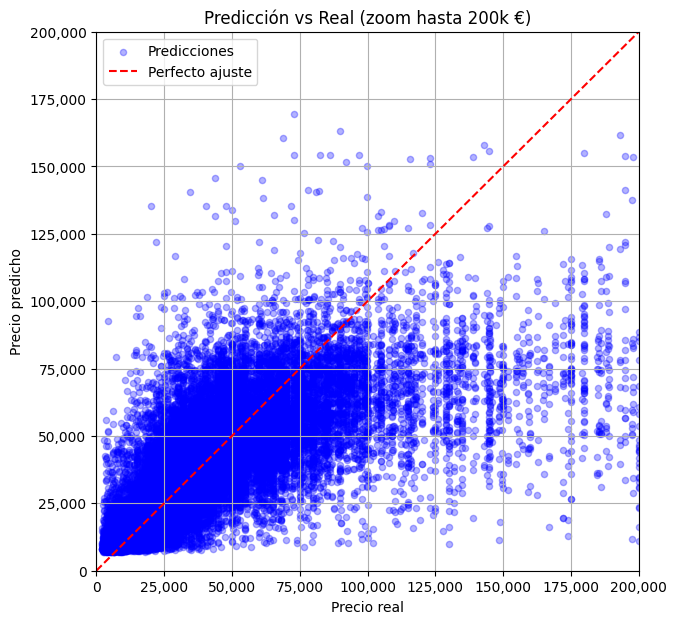

In [24]:
plt.figure(figsize=(7,7))
plt.scatter(y_test_real, np.expm1(gbr.predict(x_test)),
            alpha=0.3, s=20, color='blue', label='Predicciones')

plt.plot([0, 200_000], [0, 200_000], linestyle='--', color='red', label='Perfecto ajuste')

plt.xlim(0, 200_000)
plt.ylim(0, 200_000)

plt.xlabel('Precio real')
plt.ylabel('Precio predicho')
plt.title('Predicción vs Real (zoom hasta 200k €)')

plt.gca().xaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))
plt.gca().yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))

plt.grid(True)
plt.legend()
plt.show()


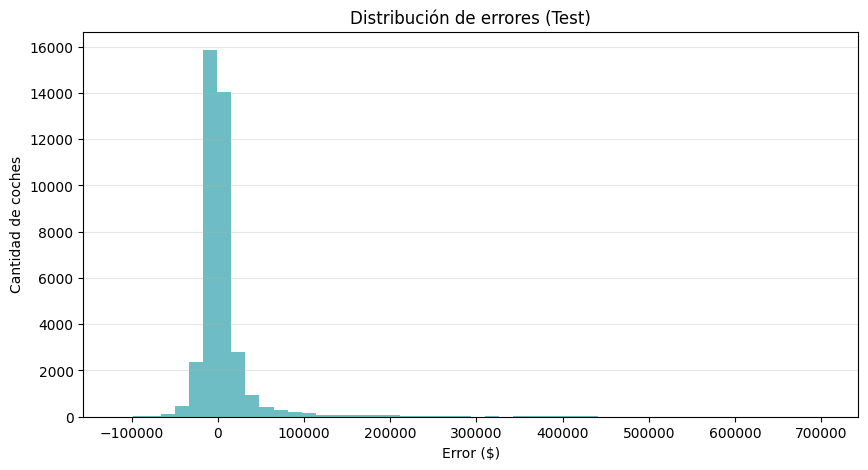

In [25]:
# Predicciones de test
y_pred_gbr_test = np.expm1(gbr.predict(x_test))

# Errores
errors = y_test_real - y_pred_gbr_test

# Histograma
plt.figure(figsize=(10,5))
plt.hist(errors, bins=50, color='#31A2AC', alpha=0.7)
plt.title('Distribución de errores (Test)')
plt.xlabel('Error ($)')
plt.ylabel('Cantidad de coches')
plt.grid(axis='y', alpha=0.3)
plt.show()


#### Comparar modelos

##### Comprobar overfiting de los modelos (%)

In [26]:
# Revertir y reales
y_train_real = np.expm1(y_train)
y_test_real  = np.expm1(y_test)

y_pred_gbr_train = np.expm1(gbr.predict(x_train))
y_pred_gbr_test  = np.expm1(gbr.predict(x_test))

y_pred_rf_train  = np.expm1(rf.predict(x_train))
y_pred_rf_test   = np.expm1(rf.predict(x_test))

y_pred_hgb_train = np.expm1(hgb.predict(x_train))
y_pred_hgb_test  = np.expm1(hgb.predict(x_test))

In [27]:
# MAE
mae_train_gbr = mean_absolute_error(y_train_real, y_pred_gbr_train)
mae_test_gbr  = mean_absolute_error(y_test_real, y_pred_gbr_test)

mae_train_rf = mean_absolute_error(y_train_real, y_pred_rf_train)
mae_test_rf  = mean_absolute_error(y_test_real, y_pred_rf_test)

mae_train_hgb = mean_absolute_error(y_train_real, y_pred_hgb_train)
mae_test_hgb  = mean_absolute_error(y_test_real, y_pred_hgb_test)

In [28]:
overfit_gbr = (mae_test_gbr - mae_train_gbr) / mae_train_gbr * 100
overfit_rf  = (mae_test_rf  - mae_train_rf)  / mae_train_rf  * 100
overfit_hgb = (mae_test_hgb - mae_train_hgb) / mae_train_hgb * 100

print("Overfitting (%) por modelo:")
print(f"GBR: {overfit_gbr:.2f}%")
print(f"RF:  {overfit_rf:.2f}%")
print(f"HGB: {overfit_hgb:.2f}%")

Overfitting (%) por modelo:
GBR: 1.24%
RF:  4.45%
HGB: 1.82%


##### Ver valores MAE, RMSE Y R2 de los modelos.

In [35]:
# --- Asegurarnos de tener y_train_real ---
y_train_real = np.expm1(y_train)

# --- Evaluar modelos en TRAIN ---
results_train = {
    'RF': evaluate_model(y_train_real, y_pred_rf_train),
    'GBR': evaluate_model(y_train_real, y_pred_gbr_train),
    'HGB': evaluate_model(y_train_real, y_pred_hgb_train),
}

# --- Convertir a DataFrame para ver resultados ---
pd.DataFrame(results_train).T

,MAE,RMSE,R2
RF,14964.298979,40038.453196,0.331231
GBR,15617.394728,40739.263681,0.307615
HGB,15416.089113,40089.962680,0.329509


#### Guardar modelos y predicciones

In [36]:
joblib.dump(hgb, "../models/csv1/hgb_model.pkl")
joblib.dump(y_test_real, "../models/csv1/y_test_real.pkl")
joblib.dump(y_pred_hgb_test, "../models/csv1/y_pred_hgb.pkl")

print("Modelo y predicciones guardadas ✅")

Modelo y predicciones guardadas ✅
